In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\course_prac\ml\regression\bigmartsales.csv")


In [4]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [5]:
df['Outlet_Size'].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [6]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [7]:
mean = df['Item_Weight'].mean()
df['Item_Weight'].fillna(mean,inplace = True)


mode = df['Outlet_Size'].mode()
df['Outlet_Size'].fillna(mode[0],inplace = True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_17820\1617551846.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(mean,inplace = True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_17820\1617551846.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [8]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [9]:
df.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1, inplace=True)
df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,Low Fat,0.016047,Dairy,249.8092,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,5.92,Regular,0.019278,Soft Drinks,48.2692,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,17.50,Low Fat,0.016760,Meat,141.6180,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,1998,Medium,Tier 3,Grocery Store,732.3800
4,8.93,Low Fat,0.000000,Household,53.8614,1987,High,Tier 3,Supermarket Type1,994.7052


In [10]:
df = pd.get_dummies(df)

In [11]:
from sklearn.model_selection import train_test_split
train,test = train_test_split(df,test_size = 0.3,random_state=42)

x_train = train.drop('Item_Outlet_Sales',axis = 1)
y_train = train['Item_Outlet_Sales']

x_test = test.drop('Item_Outlet_Sales',axis = 1)
y_test = test['Item_Outlet_Sales']

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

x_trained_scaled = scaler.fit_transform(x_train)
x_train = pd.DataFrame(x_trained_scaled)

x_test_scaled = scaler.transform(x_test)
x_test = pd.DataFrame(x_test_scaled)

In [13]:
x_test

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,0.580232,0.080087,0.204332,0.083333,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.200953,0.216619,0.048466,0.500000,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.592141,0.125805,0.045651,0.583333,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.494352,0.136322,0.604484,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.335814,0.037930,0.705527,0.791667,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,0.464126,0.500004,0.378705,0.583333,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2553,0.053885,0.097967,0.651677,0.791667,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2554,0.821375,0.453541,0.681925,0.541667,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2555,0.324204,0.115648,0.413455,0.916667,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [14]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error


In [15]:
model = neighbors.KNeighborsRegressor(n_neighbors=9)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [16]:
RMSE_val = []

for K in range(20):
  K = K + 1
  model = neighbors.KNeighborsRegressor(n_neighbors=K)
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)

  error = np.sqrt(mean_squared_error(y_test,y_pred))
  RMSE_val.append(error)
  print("rmse value of K=",K,"is:",error)

rmse value of K= 1 is: 1566.0164230571324
rmse value of K= 2 is: 1326.648190870563
rmse value of K= 3 is: 1285.5744557480352
rmse value of K= 4 is: 1246.6645231510865
rmse value of K= 5 is: 1229.2466230047837
rmse value of K= 6 is: 1205.659585077566
rmse value of K= 7 is: 1207.922493473219
rmse value of K= 8 is: 1207.9774310865034
rmse value of K= 9 is: 1207.0341003676178
rmse value of K= 10 is: 1206.4925012614206
rmse value of K= 11 is: 1213.977958973246
rmse value of K= 12 is: 1218.3580843362847
rmse value of K= 13 is: 1217.763360553212
rmse value of K= 14 is: 1221.908411967067
rmse value of K= 15 is: 1224.8730760562314
rmse value of K= 16 is: 1229.5846275442582
rmse value of K= 17 is: 1235.5190029042797
rmse value of K= 18 is: 1234.134229414351
rmse value of K= 19 is: 1240.6273165600337
rmse value of K= 20 is: 1244.3691613049793


<Axes: >

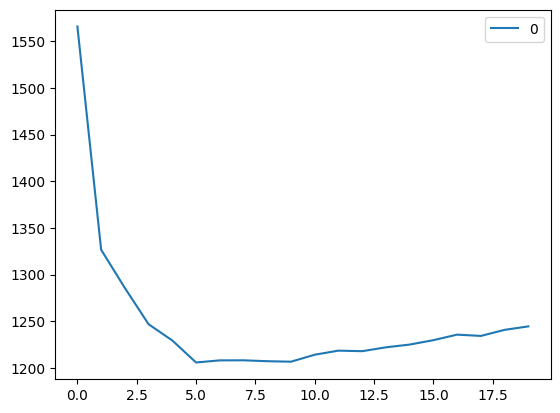

In [17]:
curve = pd.DataFrame(RMSE_val)
curve.plot()

In [18]:
test = pd.read_csv(r"C:\Users\DELL\Desktop\course_prac\ml\regression\bigmartsales_Test.csv")
submission = pd.DataFrame()
submission['Item_Identifier'] = test['Item_Identifier']
submission['Outlet_Identifier'] = test['Outlet_Identifier']

test.drop(['Item_Identifier','Outlet_Identifier'],axis = 1,inplace = True)
test['Item_Weight'].fillna(mean,inplace = True)



C:\Users\DELL\AppData\Local\Temp\ipykernel_17820\3520939147.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Item_Weight'].fillna(mean,inplace = True)


In [19]:
test = pd.get_dummies(test)
test_scaled = scaler.fit_transform(test)
test = pd.DataFrame(test_scaled)

In [20]:
pred = model.predict(test)
submission['Item_Outlet_Sales'] = pred
submission.to_csv('submit_file_for_kaggle.csv',index = False)

In [21]:
from sklearn.model_selection import GridSearchCV

params = {'n_neighbors':[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]}

knn = neighbors.KNeighborsRegressor()

model = GridSearchCV(knn,params,cv = 3)
model.fit(x_train,y_train)
model.best_params_

{'n_neighbors': 8}